# RTX 5060 observation speedups

- Compare compiled kernels and completed production NSS fits.
- Keep interpolation; reject joint-fit changes below five percent.
- Use grid schema 2.1 and seed 20260905.

In [1]:
import json
from pathlib import Path
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
                    if (p / "ceridwen/pyproject.toml").exists())
ROOT = PROJECT_ROOT / "results/rtx-5060-observation-speedups"
reports = {p.parent.name: json.loads(p.read_text()) for p in sorted(ROOT.glob("*/validation.json"))}
assert reports and all(r["numerical_passed"] for r in reports.values())
decision = json.loads((ROOT / "rejected_joint_candidates.json").read_text())
ledger = json.loads((PROJECT_ROOT / "benchmarks/ceridwen/runs/exact-speedups/vast.json").read_text())
print("GPU:", next(iter(reports.values()))["devices"])
print("Grid schema:", decision["grid_schema"], "shape:", decision["grid_shape"])
print("Production workload: 12 total-photometry bands; 6166 native spectrum pixels, 3523 fitted")
print("Calibration: marginalized order 3, coefficient prior sigma 0.1; spectrum scaling free")
print("Sampler: BlackJAX NSS, 500 live, 65 inner steps, 100 deleted, logZ tolerance -5")
print("Software:", next(iter(reports.values()))["software"])
print("Billed USD:", sum(r["billed_usd"] for r in ledger))
print(decision["reason"])


GPU: ['NVIDIA GeForce RTX 5060']
Grid schema: 2.1 shape: [5, 13, 107, 10992]
Production workload: 12 total-photometry bands; 6166 native spectrum pixels, 3523 fitted
Calibration: marginalized order 3, coefficient prior sigma 0.1; spectrum scaling free
Sampler: BlackJAX NSS, 500 live, 65 inner steps, 100 deleted, logZ tolerance -5
Software: {'jax': '0.10.2', 'jaxlib': '0.10.2', 'blackjax': '1.6.dev98+gf73e12956', 'ceridwen': '0.2.3', 'sedpy-jax': '0.1.1'}
Billed USD: 0.311
Wavelength selection and Cholesky calibration both missed the 5 percent speedup gate.


- Synchronize each timed batch; exclude compilation and warmup.
- Separate interpolation timing from the smoothed joint-fit workload.

,joint likelihood ratio,default dense / gather,full-precision dense / gather
posterior,,,
baseline,1.000601,11.261309,4.249006
candidate,0.998320,11.477191,4.293065


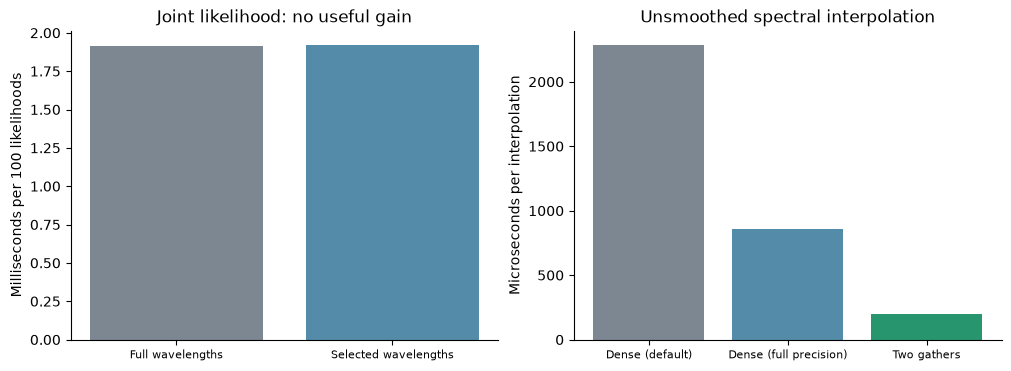

In [2]:
timing_rows = []
for name, r in reports.items():
    dense = np.median(r["interpolation_seconds"]["dense"])
    highest = np.median(r["interpolation_seconds"]["dense_highest"])
    gather = np.median(r["interpolation_seconds"]["gather"])
    timing_rows.append({"posterior": r["fit_arm"],
                       "joint likelihood ratio": r["likelihood_speedup"],
                       "default dense / gather": dense / gather,
                       "full-precision dense / gather": highest / gather})
display(pd.DataFrame(timing_rows).set_index("posterior"))
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), layout="constrained")
for ax, field, names, labels, factor, ylabel in [
    (axes[0], "batch_seconds", ["baseline", "candidate"],
     ["Full wavelengths", "Selected wavelengths"], 1e3, "Milliseconds per 100 likelihoods"),
    (axes[1], "interpolation_seconds", ["dense", "dense_highest", "gather"],
     ["Dense (default)", "Dense (full precision)", "Two gathers"], 1e6, "Microseconds per interpolation")]:
    values = [np.concatenate([r[field][name] for r in reports.values()]) * factor for name in names]
    ax.bar(labels, [np.median(v) for v in values], color=["#7d8791", "#548ba9", "#27956e"][:len(names)])
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_title("Joint likelihood: no useful gain")
axes[1].set_title("Unsmoothed spectral interpolation")
plt.show()


- Compare interpolation with float64 arithmetic using identical matrix coefficients.
- Default CUDA matrix multiplication uses reduced precision here.

In [3]:
accuracy = []
for r in reports.values():
    accuracy.append({"posterior": r["fit_arm"],
                     "prediction error / uncertainty": max(r["prediction_error_in_sigma"].values()),
                     "absolute likelihood difference": r["max_abs_loglike_error"],
                     "relative gradient difference": r["max_relative_gradient_error"],
                     **{k + " interpolation relative error": v for k, v in
                        r["interpolation_relative_error_vs_float64"].items()}})
display(pd.DataFrame(accuracy).set_index("posterior").T)
probe = next(r["calibration_probe"] for r in reports.values() if r.get("calibration_probe"))
print("Cholesky likelihood speed ratio:", probe["speedup"])
print("Cholesky maximum absolute likelihood difference:", probe["max_abs_loglike_error"])


posterior,baseline,candidate
prediction error / uncertainty,0.000000e+00,0.000000e+00
absolute likelihood difference,0.000000e+00,0.000000e+00
relative gradient difference,1.417330e-05,4.263649e-06
dense interpolation relative error,6.621487e-04,6.621487e-04
dense_highest interpolation relative error,1.074529e-07,1.074529e-07
gather interpolation relative error,1.074529e-07,1.074529e-07


Cholesky likelihood speed ratio: 0.9962857934160138
Cholesky maximum absolute likelihood difference: 9.313225746154785e-10


- Separate sampler iterations from synchronized likelihood timing.
- Two fits cannot establish equivalence across independent sampling seeds.

In [4]:
fits = {}
rows = []
for p in sorted(ROOT.glob("*/ceridwen_result.h5")):
    arm = p.parent.name.rsplit("-", 1)[-1]
    with h5py.File(p) as f:
        attrs = dict(f["samples"].attrs)
    with h5py.File(p.parent / "ceridwen_derived_outputs.h5") as f:
        assert f["diagnostics"].attrs["passed"]
        fits[arm] = {"attrs": attrs,
                     "parameter": f["summary/parameter"].asstr()[:],
                     "q16": f["summary/q16"][:], "q50": f["summary/q50"][:], "q84": f["summary/q84"][:],
                     "lookback": f["sfh/lookback_time_gyr"][:],
                     "sfr16": f["sfh/normalized_sfr_q16"][:],
                     "sfr50": f["sfh/normalized_sfr_q50"][:],
                     "sfr84": f["sfh/normalized_sfr_q84"][:]}
        rows.append({"arm": arm, "reported sampler seconds": attrs["wall_time_s"],
                     "reported likelihood calls": attrs["n_likelihood_calls"],
                     "log evidence": attrs["log_evidence"], "evidence error": attrs["log_evidence_err"],
                     "posterior weight ESS": f["diagnostics"].attrs["posterior_weight_ess"]})
display(pd.DataFrame(rows).set_index("arm"))
base, candidate = fits["baseline"], fits["candidate"]
width = .5 * (base["q84"] - base["q16"])
keep = width > 0
posterior = pd.DataFrame({"parameter": base["parameter"][keep],
                         "baseline median": base["q50"][keep],
                         "candidate median": candidate["q50"][keep],
                         "median difference / half 68% width":
                         (candidate["q50"][keep] - base["q50"][keep]) / width[keep]})
display(posterior.set_index("parameter"))
print("Evidence difference:", candidate["attrs"]["log_evidence"] - base["attrs"]["log_evidence"])
print("Independent-seed validation was stopped after the speed gate failed.")


,reported sampler seconds,reported likelihood calls,log evidence,evidence error,posterior weight ESS
arm,,,,,
baseline,450.27445,1378000,230655.867672,0.290425,3733.488956
candidate,437.50674,1352000,230656.804366,0.212912,3428.431325


,baseline median,candidate median,median difference / half 68% width
parameter,,,
logsfr_ratios[0],2.542181,2.526600,-0.035118
logsfr_ratios[1],1.183531,1.970036,0.854929
logsfr_ratios[2],-0.185307,-0.505865,-0.259241
logsfr_ratios[3],-1.373991,-1.814954,-0.577645
logsfr_ratios[4],-2.763258,-2.822854,-0.296287
logsfr_ratios[5],0.391104,0.381159,-0.046775
logsfr_ratios[6],1.374513,1.211211,-0.141268
logmass,11.564740,11.568833,0.269882
Z,-1.596428,-1.595483,0.046642


Evidence difference: 0.9366940972104203
Independent-seed validation was stopped after the speed gate failed.


- Compare the saved star-formation histories from both completed fits.

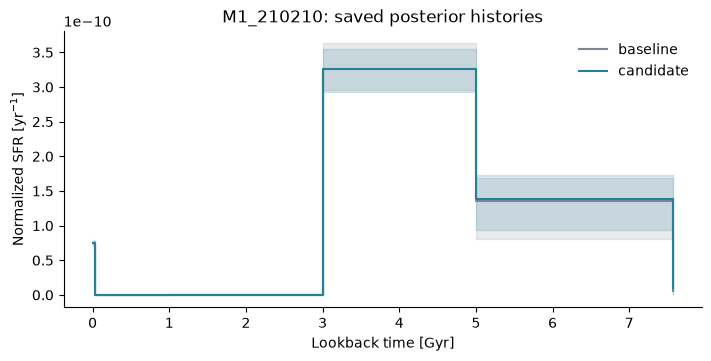

In [5]:
fig, ax = plt.subplots(figsize=(7, 3.5), layout="constrained")
for arm, colour in [("baseline", "#7d8791"), ("candidate", "#287f99")]:
    fit = fits[arm]
    ax.step(fit["lookback"], fit["sfr50"], where="post", label=arm, color=colour)
    ax.fill_between(fit["lookback"], fit["sfr16"], fit["sfr84"], step="post", color=colour, alpha=.17)
ax.set(xlabel="Lookback time [Gyr]", ylabel=r"Normalized SFR [$\mathrm{yr}^{-1}$]",
       title="M1_210210: saved posterior histories")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
plt.show()
